In [1]:
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


##1. Dataset Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/sales_data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (76000, 16)


##2. Display the dataset

In [3]:
df.head(10)
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73


##3. Dataset information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

##4. Check missing values

In [5]:
df.isnull().sum()

,0
Date,0
Store ID,0
Product ID,0
Category,0
Region,0
Inventory Level,0
Units Sold,0
Units Ordered,0
Price,0
Discount,0


##5. Check duplicate records

In [6]:
df.duplicated().sum()

np.int64(0)

##6. Convert Date

In [7]:
df["Date"] = pd.to_datetime(df["Date"])

print("Date converted successfully!")
print(df["Date"].dtype)

Date converted successfully!
datetime64[ns]


##7. Check date range

In [8]:
print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())
print("Unique dates:", df["Date"].nunique())

Start date: 2022-01-01 00:00:00
End date: 2024-01-30 00:00:00
Unique dates: 760


##8. Check categorical columns

In [9]:
print("Categories:")
print(df["Category"].unique())

print("\nRegions:")
print(df["Region"].unique())

print("\nWeather Conditions:")
print(df["Weather Condition"].unique())

print("\nSeasonality:")
print(df["Seasonality"].unique())

print("\nStores:")
print(df["Store ID"].unique())

print("\nProducts:")
print(df["Product ID"].unique())

Categories:
['Electronics' 'Clothing' 'Groceries' 'Toys' 'Furniture']

Regions:
['North' 'South' 'East' 'West']

Weather Conditions:
['Snowy' 'Cloudy' 'Sunny' 'Rainy']

Seasonality:
['Winter' 'Spring' 'Summer' 'Autumn']

Stores:
['S001' 'S002' 'S003' 'S004' 'S005']

Products:
['P0001' 'P0002' 'P0003' 'P0004' 'P0005' 'P0006' 'P0007' 'P0008' 'P0009'
 'P0010' 'P0011' 'P0012' 'P0013' 'P0014' 'P0015' 'P0016' 'P0017' 'P0018'
 'P0019' 'P0020']


##9. Numerical analysis

In [10]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,2023-01-15 12:00:00,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,2022-07-09 18:00:00,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,2023-01-15 12:00:00,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,2023-07-24 06:00:00,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2024-01-30 00:00:00,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000
std,NaN,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801


##10. Check important pricing values

In [11]:
print("Discount values:", sorted(df["Discount"].unique()))
print("Promotion values:", sorted(df["Promotion"].unique()))
print("Epidemic values:", sorted(df["Epidemic"].unique()))

Discount values: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
Promotion values: [np.int64(0), np.int64(1)]
Epidemic values: [np.int64(0), np.int64(1)]


##11. Check negative values

In [12]:
print("Negative Price:", (df["Price"] < 0).sum())
print("Negative Competitor Pricing:",
      (df["Competitor Pricing"] < 0).sum())
print("Negative Inventory:",
      (df["Inventory Level"] < 0).sum())
print("Negative Units Sold:",
      (df["Units Sold"] < 0).sum())
print("Negative Demand:",
      (df["Demand"] < 0).sum())

Negative Price: 0
Negative Competitor Pricing: 0
Negative Inventory: 0
Negative Units Sold: 0
Negative Demand: 0


##12. Average Demand by Category

In [17]:
demand_category = df.groupby("Category")["Demand"].mean()

print(demand_category)

Category
Clothing       112.619737
Electronics     97.482018
Furniture       73.581140
Groceries      120.976447
Toys            92.606955
Name: Demand, dtype: float64


##Visualization

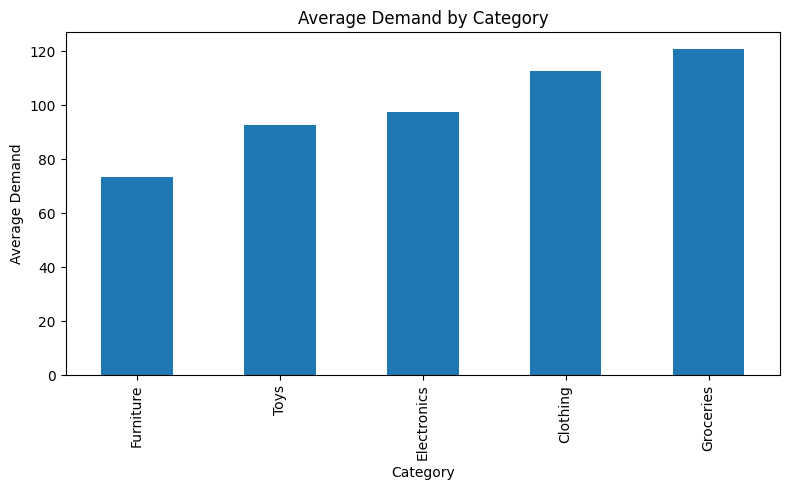

In [18]:
plt.figure(figsize=(8,5))

demand_category.sort_values().plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Average Demand")
plt.title("Average Demand by Category")

plt.tight_layout()
plt.show()

##13. Average Demand by Region

In [22]:
demand_region = df.groupby("Region")["Demand"].mean()

print(demand_region)

Region
East     106.468684
North    103.771645
South    106.938882
West     100.634934
Name: Demand, dtype: float64


##Visualization

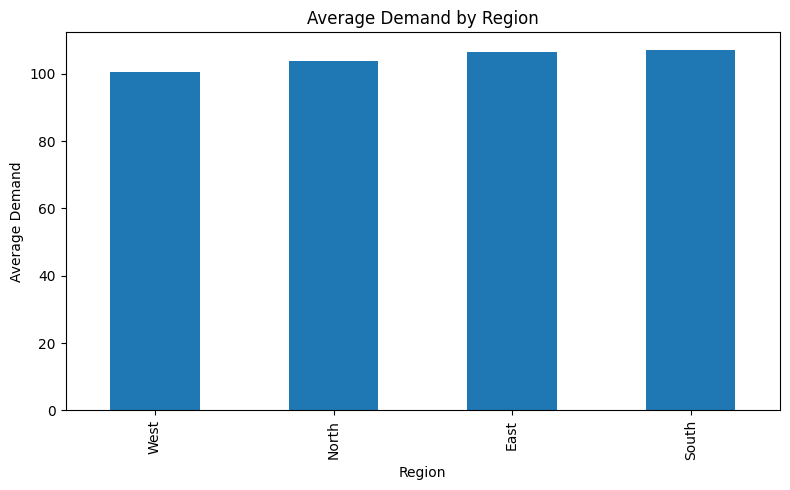

In [21]:
plt.figure(figsize=(8,5))

demand_region.sort_values().plot(kind="bar")

plt.xlabel("Region")
plt.ylabel("Average Demand")
plt.title("Average Demand by Region")

plt.tight_layout()
plt.show()

##14.Demand vs Weather

In [23]:
demand_weather = df.groupby(
    "Weather Condition"
)["Demand"].mean()

print(demand_weather)

Weather Condition
Cloudy    105.404064
Rainy      95.106743
Snowy      94.045789
Sunny     115.167189
Name: Demand, dtype: float64


##Visualization

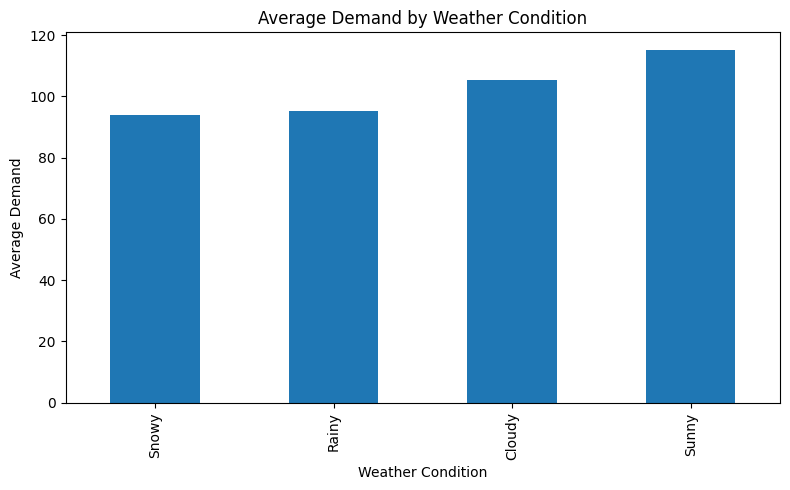

In [24]:
plt.figure(figsize=(8,5))

demand_weather.sort_values().plot(kind="bar")

plt.xlabel("Weather Condition")
plt.ylabel("Average Demand")
plt.title("Average Demand by Weather Condition")

plt.tight_layout()
plt.show()

##15. Demand vs Seasonality

In [25]:
demand_season = df.groupby(
    "Seasonality"
)["Demand"].mean()

print(demand_season)

Seasonality
Autumn    103.422967
Spring     97.703098
Summer    112.855380
Winter    103.406190
Name: Demand, dtype: float64


##Visualization

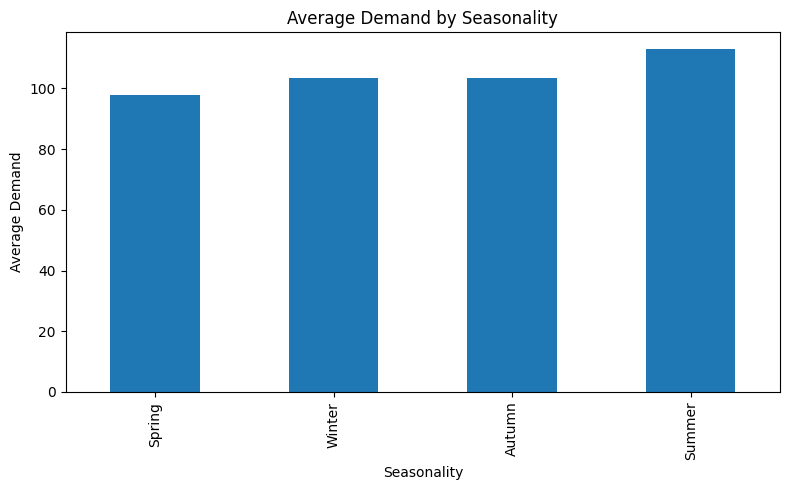

In [26]:
plt.figure(figsize=(8,5))

demand_season.sort_values().plot(kind="bar")

plt.xlabel("Seasonality")
plt.ylabel("Average Demand")
plt.title("Average Demand by Seasonality")

plt.tight_layout()
plt.show()

##16. Price vs Demand

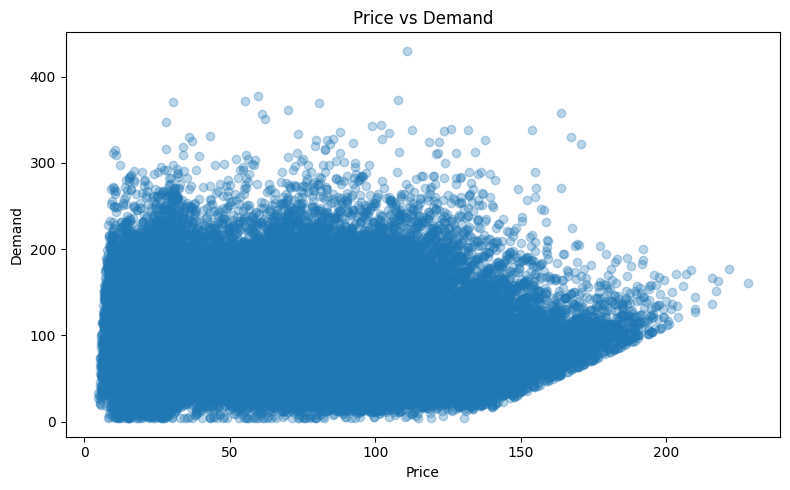

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Price"],
    df["Demand"],
    alpha=0.3
)

plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Price vs Demand")

plt.tight_layout()
plt.show()

##17. Competitor Pricing vs Demand

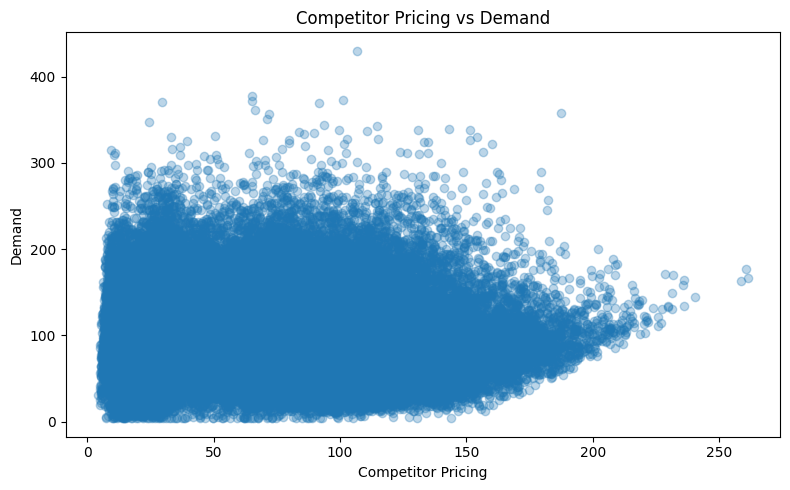

In [41]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Competitor Pricing"],
    df["Demand"],
    alpha=0.3
)

plt.xlabel("Competitor Pricing")
plt.ylabel("Demand")
plt.title("Competitor Pricing vs Demand")

plt.tight_layout()
plt.show()

##18. Discount vs Demand

In [42]:
discount_demand = df.groupby(
    "Discount"
)["Demand"].mean()

print(discount_demand)

Discount
0      94.748861
5      94.941896
10    102.767834
15    123.575981
20    124.065256
25    122.967374
Name: Demand, dtype: float64


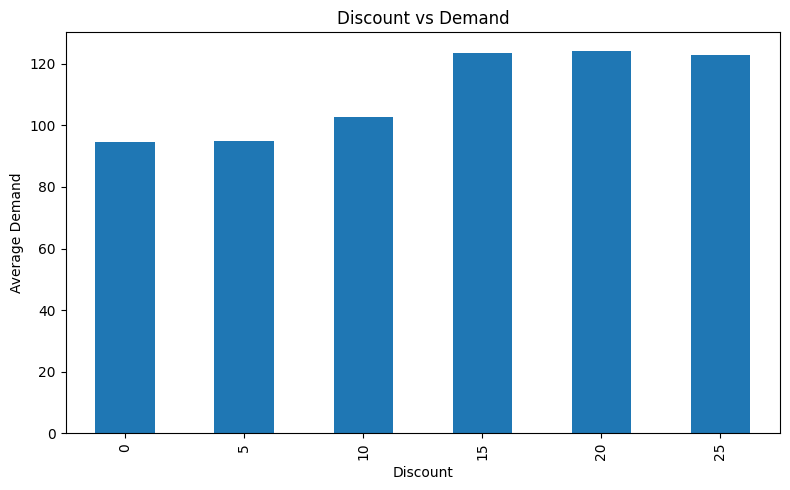

In [43]:
plt.figure(figsize=(8,5))

discount_demand.sort_index().plot(kind="bar")

plt.xlabel("Discount")
plt.ylabel("Average Demand")
plt.title("Discount vs Demand")

plt.tight_layout()
plt.show()

##19. Promotion vs Demand

In [44]:
promotion_demand = df.groupby(
    "Promotion"
)["Demand"].mean()

print(promotion_demand)

Promotion
0     95.026843
1    123.269400
Name: Demand, dtype: float64


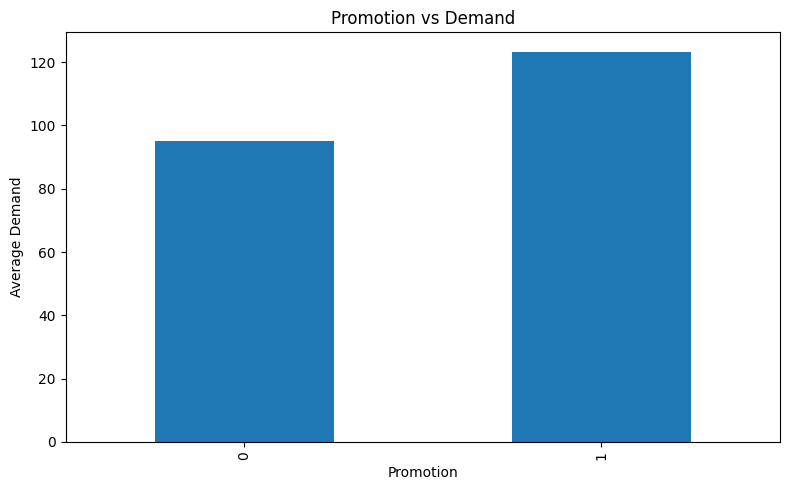

In [45]:
plt.figure(figsize=(8,5))

promotion_demand.plot(kind="bar")

plt.xlabel("Promotion")
plt.ylabel("Average Demand")
plt.title("Promotion vs Demand")

plt.tight_layout()
plt.show()

##20.Averages

In [34]:
print("Average Demand:",df["Demand"].mean())
print("Average Price:",df["Price"].mean())
print("Average Competitor Price:",df["Competitor Pricing"].mean())
print("Average Inventory:",df["Inventory Level"].mean())
print("Price-Demand Correlation:",df["Price"].corr(df["Demand"]))
print("Competitor Price-Demand Correlation:",df["Competitor Pricing"].corr(df["Demand"]))
print("Inventory-Demand Correlation:",df["Inventory Level"].corr(df["Demand"]))


Average Demand: 104.31715789473684
Average Price: 67.7260275
Average Competitor Price: 69.45402907894737
Average Inventory: 301.06284210526314
Price-Demand Correlation: -0.02346082195720525
Competitor Price-Demand Correlation: -0.023036445032016562
Inventory-Demand Correlation: 0.12661807535498754


##21. Correlation analysis

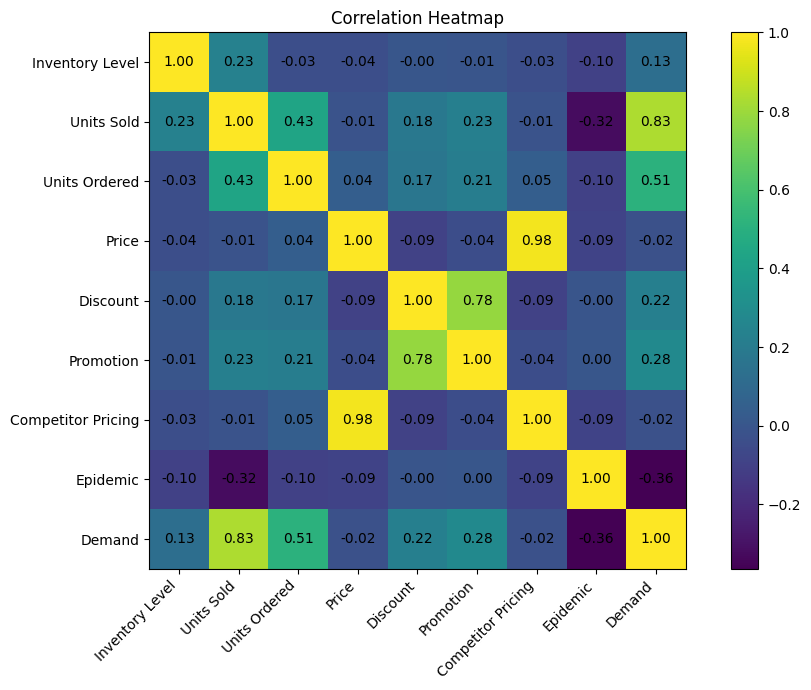

In [52]:
import matplotlib.pyplot as plt
# Select numerical columns
numeric_columns = [
    "Inventory Level",
    "Units Sold",
    "Units Ordered",
    "Price",
    "Discount",
    "Promotion",
    "Competitor Pricing",
    "Epidemic",
    "Demand"
]

# Create heatmap
plt.figure(figsize=(10, 7))

plt.imshow(
    correlation,
    interpolation="nearest"
)

plt.colorbar()

# Add labels
plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

##22. Price Difference

In [37]:
df["Price Difference"] = (
    df["Price"] - df["Competitor Pricing"]
)
print(df["Price Difference"].describe())
df[[
    "Price",
    "Competitor Pricing",
    "Price Difference"
]].head()

count    76000.000000
mean        -1.728002
std          8.817663
min        -45.380000
25%         -7.230000
50%          0.030000
75%          3.750000
max         33.090000
Name: Price Difference, dtype: float64


,Price,Competitor Pricing,Price Difference
0,72.72,85.73,-13.01
1,80.16,92.02,-11.86
2,62.94,60.08,2.86
3,87.63,85.19,2.44
4,54.41,51.63,2.78
